# Anatomy of a Detector
## IoU, NMS, and a mini-YOLO on Chinchero textiles

**Hands-on lab — approximately 120 minutes · Lab 5 of the series · PyTorch**

Lab 4 ended on a cliffhanger: your CNN can name a motif *when someone hands it a
crop* — but the crops came from human annotations. Today you build the machinery that
finds the boxes itself. Not by downloading a mystery model: you will implement every
conceptual building block of a modern detector — **IoU**, **non-max suppression**, the
**grid trick**, a **multi-part detection loss** — small enough to read, real enough to
train on the Chinchero photographs.

**What you will do**

| # | Section | Time |
|---|---------|------|
| 1 | From classifier to detector | 5 min |
| 2 | IoU — the ruler of detection | 12 min |
| 3 | Non-max suppression | 12 min |
| 4 | Making it trainable: tiles (and a new leakage trap) | 12 min |
| 5 | Localization is just regression | 18 min |
| 6 | Mini-YOLO: a grid of localizers | 35 min |
| 7 | Honest evaluation: precision, recall, AP@0.5 | 12 min |
| 8 | The industry detector: same contract, bigger machine | 8 min |
| 9 | Wrap-up and homework | — |

**Prerequisites:** Labs 1–4. You will reuse Lab 4's YOLO-label tools, Dataset/collate
patterns, and training loop — and Labs 1–3's losses and discipline at every turn.

**Environment:** Colab GPU recommended; auto-detected `FAST_MODE` keeps everything
runnable on CPU. A **pre-trained mini-YOLO checkpoint ships with this lab**
(`miniyolo_checkpoint.pt`) so the visualization and evaluation sections work even if
your own training run is short.

**Philosophy:** the goal is not the best detector — Lab 5's detector is deliberately
minimal. The goal is that nothing in YOLO or Faster R-CNN feels like magic afterwards.


> **STUDENT VERSION** — complete the cells marked `TODO 1`–`TODO 5`. Each is followed by a check cell; a hint is hidden below each TODO. All other cells are ready to run.

## 0. Setup

In [ ]:
import os, time, random, ast, re
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FAST_MODE = False
print(f"torch {torch.__version__} | device: {DEVICE} | FAST_MODE: {FAST_MODE}")

C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a",
     "yellow": "#eda100", "red": "#e34948", "ink": "#0b0b0b",
     "muted": "#898781", "grid": "#e1e0d9"}
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["grid"], "grid.linewidth": 0.8,
    "axes.edgecolor": "#c3c2b7", "font.size": 10.5, "axes.titlesize": 12})

torch 2.11.0+cu128 | device: cuda | FAST_MODE: False


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ---- Locate the dataset (same logic as Lab 4) ----------------------------------
# from google.colab import drive; drive.mount('/content/drive')   # <- Colab
CANDIDATE_ROOTS = ["/content/drive/MyDrive/Iconography_Chinchero",
                   "/content/Iconography_Chinchero",
                   "./Iconography_Chinchero", "./data_sample",
                   "/home/claude/lab4/data_sample"]
DATA_ROOT = next((Path(p) for p in CANDIDATE_ROOTS
                  if (Path(p) / "classes_name.yaml").exists()), None)
assert DATA_ROOT is not None, "edit CANDIDATE_ROOTS to point at the dataset folder"
IMG_DIR = next(p for p in DATA_ROOT.rglob("images") if p.is_dir())
LBL_DIR = next(p for p in DATA_ROOT.rglob("labels") if p.is_dir())
CLASS_NAMES = ast.literal_eval(re.search(r"names:\s*(\[.*\])",
    (DATA_ROOT / "classes_name.yaml").read_text()).group(1))
NUM_CLASSES = len(CLASS_NAMES)
image_paths = sorted(IMG_DIR.glob("*.jpg"))
print(f"{len(image_paths)} images | {NUM_CLASSES} classes | root: {DATA_ROOT}")

1358 images | 28 classes | root: /content/drive/MyDrive/Iconography_Chinchero


In [ ]:
# ---- The Lab 4 toolbox (your own solutions, provided ready-made) -----------------
def parse_yolo_file(path):
    path = Path(path)
    if not path.exists(): return []
    rows = []
    for line in path.read_text().strip().splitlines():
        p = line.split()
        if len(p) >= 5: rows.append((int(p[0]), *map(float, p[1:5])))
    return rows

def yolo_to_xyxy(cx, cy, w, h, W, H):
    x1, y1 = (cx - w/2) * W, (cy - h/2) * H
    x2, y2 = (cx + w/2) * W, (cy + h/2) * H
    return max(0.0, x1), max(0.0, y1), min(float(W), x2), min(float(H), y2)

def draw_boxes(ax, boxes_xyxy, color, lw=1.6, labels=None):
    '''boxes in pixel xyxy on whatever image the axis shows.'''
    for k, (x1, y1, x2, y2) in enumerate(boxes_xyxy):
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                               edgecolor=color, linewidth=lw))
        if labels is not None:
            ax.text(x1, y1 - 2, labels[k], color=color, fontsize=7)

print("toolbox ready")

toolbox ready


## 1. From classifier to detector  *(~5 min)*

A detector answers three questions for every image: **how many** objects, **where**
each one is, and **what** each one is. Lab 4's classifier answers only the last, and
only when handed a crop. The gap between the two is bridged by four ideas, and this
lab builds them in order:

1. **IoU** — before we can train or judge a detector, we need a number for "these two
   boxes agree". (Section 2)
2. **NMS** — detectors fire many overlapping guesses per object; we need a principled
   de-duplicator. (Section 3)
3. **Localization as regression** — predicting a box is just predicting 4 numbers;
   Lab 1 taught you to regress numbers, Lab 2 to classify — a detector head does both
   at once. (Section 5)
4. **The grid trick** — to find *many* objects, run a tiny localizer in every cell of
   an S×S grid over the image. That is, almost verbatim, YOLO. (Section 6)

One practical obstacle first: EDA in Lab 4 showed a median of ~47 motifs per
photograph (max 1,625!). No introductory detector can learn that density directly —
Section 4 slices the photos into **tiles** so each training sample carries a handful
of boxes. Detection people do this routinely (satellite and medical imagery
especially); it is not a hack, it is the standard answer to dense small objects.

## 2. IoU — the ruler of detection  *(~12 min)*

**Intersection over Union** measures how well two boxes agree:

$$\text{IoU}(A, B) = \frac{\text{area}(A \cap B)}{\text{area}(A \cup B)} \in [0, 1]$$

0 = disjoint, 1 = identical. Everything downstream uses it: NMS suppresses boxes with
high IoU to a better-scoring box; evaluation counts a prediction as correct when its
IoU with a ground-truth box exceeds a threshold (0.5 is the classic).

The implementation trick: the intersection of two axis-aligned boxes is itself a box,
whose corners are `max` of the top-left corners and `min` of the bottom-right corners.
If that "box" has negative width or height, the boxes don't overlap at all.

#More about IoU

IoU là một chỉ số đo lường độ chính xác của bounding boxes, về thực chất thì là các tọa độ (x,y), của mô hình dự đoán so với thực tế (ground-truth). Thường thì IoU > 0,5 được coi là tốt.

In [ ]:
def iou(box_a, box_b):
    '''
    IoU of two boxes in (x1, y1, x2, y2) format (any consistent units).

    Returns: float in [0, 1].
    '''
    ### ===== TODO 1 (≈ 6 lines) ================================= ###
    # 1) intersection corners: ix1 = max of the two x1's, iy1 = max of
    #    the y1's, ix2 = min of the x2's, iy2 = min of the y2's
    # 2) inter = max(0, ix2-ix1) * max(0, iy2-iy1)   <- the max(0, .)
    #    handles non-overlapping boxes
    # 3) union = area_a + area_b - inter   (why subtract? draw it!)
    # 4) return inter / union   (guard against union == 0)
    ix1 = max(box_a[0], box_b[0])
    iy1 = max(box_a[1], box_b[1])
    ix2 = min(box_a[2], box_b[2])
    iy2 = min(box_a[3], box_b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = ((box_a[2] - box_a[0]) * (box_a[3]- box_a[1])) + ((box_b[2] - box_b[0]) * (box_b[3]- box_b[1])) - inter
    return inter/union if union > 0 else 0.0
    ### ===== END TODO ============================================ ###

<details><summary><b>Hint — TODO 1</b></summary>

`ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])` and
`ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])`. Intersection area
`max(0, ix2-ix1) * max(0, iy2-iy1)`. Union = sum of both areas minus the
intersection (it was counted twice). Return `inter/union` with a
`if union > 0 else 0.0` guard.
</details>

In [ ]:
# ---- Check TODO 1: iou -------------------------------------------------------------
# All three cases are hand-checkable:
t1 = iou((0, 0, 2, 2), (1, 1, 3, 3))   # inter 1x1=1, union 4+4-1=7 -> 1/7
t2 = iou((0, 0, 2, 2), (0, 0, 2, 2))   # identical -> 1
t3 = iou((0, 0, 1, 1), (2, 2, 3, 3))   # disjoint  -> 0
print(f"overlapping: {t1:.4f}   (expected 0.1429 = 1/7)")
print(f"identical:   {t2:.4f}   (expected 1.0)")
print(f"disjoint:    {t3:.4f}   (expected 0.0)")
assert t1 is not None, "iou returned None"
assert abs(t1 - 1/7) < 1e-9 and t2 == 1.0 and t3 == 0.0, "check the formulas"
# touching edges only -> zero overlap:
assert iou((0, 0, 1, 1), (1, 0, 2, 1)) == 0.0
print("PASSED: iou is correct")

overlapping: 0.1429   (expected 0.1429 = 1/7)
identical:   1.0000   (expected 1.0)
disjoint:    0.0000   (expected 0.0)
PASSED: iou is correct


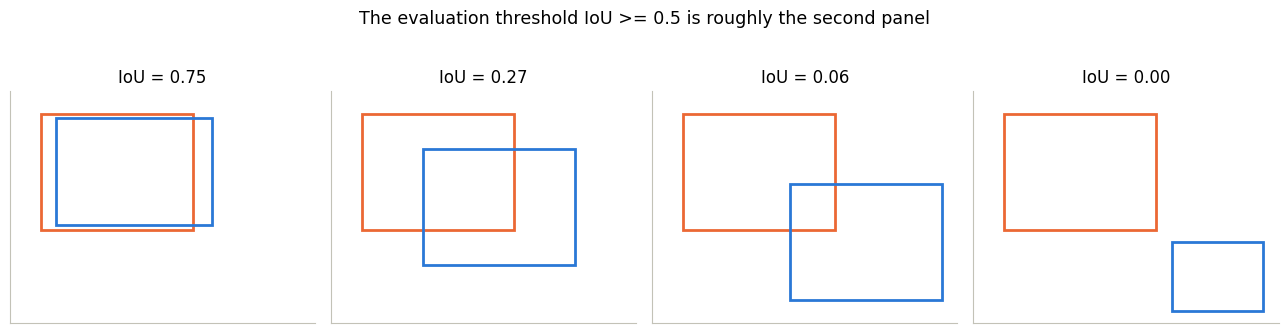

In [ ]:
# What IoU values LOOK like - calibrate your eyes (given):
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
cases = [((10, 10, 60, 60), (15, 12, 66, 58)), ((10, 10, 60, 60), (30, 25, 80, 75)),
         ((10, 10, 60, 60), (45, 40, 95, 90)), ((10, 10, 60, 60), (65, 65, 95, 95))]
for ax, (a, b) in zip(axes, cases):
    ax.add_patch(Rectangle(a[:2], a[2]-a[0], a[3]-a[1], fill=False,
                           edgecolor=C["orange"], lw=2))
    ax.add_patch(Rectangle(b[:2], b[2]-b[0], b[3]-b[1], fill=False,
                           edgecolor=C["blue"], lw=2))
    ax.set(xlim=(0, 100), ylim=(100, 0), title=f"IoU = {iou(a, b):.2f}")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("The evaluation threshold IoU >= 0.5 is roughly the second panel", y=1.03)
plt.tight_layout(); plt.show()

## 3. Non-max suppression  *(~12 min)*

A grid detector fires one prediction per cell — so a motif spanning several cells gets
detected several times, with slightly different boxes and scores. **NMS** cleans this
up with a greedy rule that you can state in one breath:

> Repeatedly take the highest-scoring remaining box; kill every remaining box that
> overlaps it by more than a threshold; repeat until none remain.

That's the whole algorithm (this is also, essentially, the function Andrew Ng's deep
learning course asks students to implement — it is *the* classic exercise of
detection).

In [ ]:
def nms(boxes, scores, iou_threshold=0.4):
    '''
    Greedy non-max suppression.

    Args:
        boxes  : list of (x1, y1, x2, y2)
        scores : list of floats (confidence), same length
        iou_threshold : overlap above which a lower-scoring box is suppressed
    Returns:
        list of indices of the KEPT boxes, in decreasing-score order.
    '''
    ### ===== TODO 2 (≈ 7 lines) ================================= ###
    # 1) order = indices sorted by score, highest first
    # 2) loop while order is not empty:
    #      - pop the first index -> it is KEPT
    #      - filter order: drop every i whose iou(kept_box, boxes[i])
    #        is >= iou_threshold        (reuse YOUR iou from TODO 1!)
    # 3) return the kept indices
    order = sorted(range(len(boxes)), key=lambda i: scores[i], reverse=True)
    keep = []
    while len(order) > 0:
      best_box_idx = order.pop(0)
      keep.append(best_box_idx)
      order = [i for i in order if iou(boxes[best_box_idx], boxes[i]) < iou_threshold]
    return keep

    ### ===== END TODO ============================================ ###

<details><summary><b>Hint — TODO 2</b></summary>

`order = sorted(range(len(boxes)), key=lambda i: scores[i], reverse=True)`. Then:
`best = order.pop(0)`, `keep.append(best)`,
`order = [i for i in order if iou(boxes[best], boxes[i]) < iou_threshold]`, loop
until `order` is empty.
</details>

In [ ]:
# ---- Check TODO 2: nms --------------------------------------------------------------
# Three boxes: A and B overlap heavily (B scores lower -> suppressed), C is far away.
boxes_t  = [(0, 0, 10, 10), (1, 1, 11, 11), (50, 50, 60, 60)]
scores_t = [0.9, 0.8, 0.7]
kept = nms(boxes_t, scores_t, iou_threshold=0.4)
print("kept indices:", kept, "  expected: [0, 2]")
assert kept is not None, "nms returned None"
assert kept == [0, 2], "A should suppress B; C survives"
assert nms(boxes_t, [0.8, 0.9, 0.7], 0.4) == [1, 2], "the HIGHER-scoring box must win"
assert nms(boxes_t, scores_t, iou_threshold=0.95) == [0, 1, 2], \
    "with a very high threshold nothing is suppressed"
print("PASSED: nms is correct")

kept indices: [0, 2]   expected: [0, 2]
PASSED: nms is correct


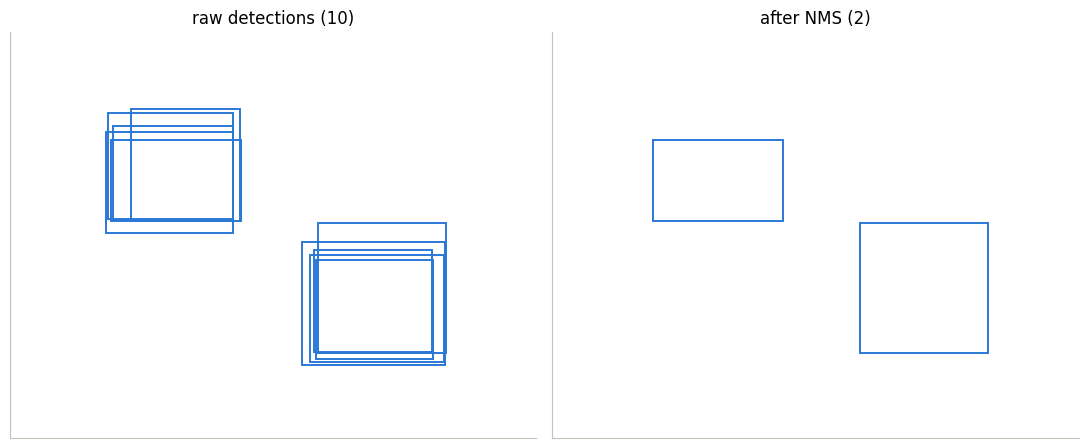

NMS kept 2 of 10 boxes - one per real object


In [ ]:
# NMS in one picture (given): duplicate detections around two real motifs
rng = np.random.default_rng(3) # tạo ra bộ 3 số ngẫu nhiên cố định
true_boxes = [(20, 25, 45, 50), (60, 55, 85, 85)]
dup_boxes, dup_scores = [], []
for bx in true_boxes:
    for _ in range(5):
        j = rng.normal(0, 2.0, 4) # mảng gồm 4 số ngẫu nhiên nhỏ
        dup_boxes.append((bx[0]+j[0], bx[1]+j[1], bx[2]+j[2], bx[3]+j[3])) # tạo các hộp dự đoán mới lệch một chút
        dup_scores.append(float(rng.uniform(0.5, 0.95))) # gắn cho các hộp các điểm độ tự tin ngẫu nhiên từ 0.5 đến 0.95
keep = nms(dup_boxes, dup_scores, 0.4) # các hộp sau khi qua nms

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, idxs, ttl in [(axes[0], range(len(dup_boxes)), f"raw detections ({len(dup_boxes)})"),
                      (axes[1], keep, f"after NMS ({len(keep)})")]:
    draw_boxes(ax, [dup_boxes[i] for i in idxs], C["blue"], lw=1.4)
    ax.set(xlim=(0, 105), ylim=(105, 0), title=ttl)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
print("NMS kept", len(keep), "of", len(dup_boxes), "boxes - one per real object")

## 4. Making it trainable: tiles  *(~12 min)*

Lab 4's EDA verdict: ~47 motifs per photo on average. A grid detector with S×S = 49
cells and one box per cell would be saturated by the *median* image — and the 1,625-box
image is hopeless. The standard remedy for dense small objects is to **tile**: cut each
4896×3672 photo into a 4×3 grid of patches; each tile now carries a handful of motifs.
Boxes are clipped to their tile and re-normalized to tile coordinates; a box that barely
pokes into a tile (< 25% of its area) is dropped. (Given code — the geometry is Lab 4's
`yolo_to_xyxy` in reverse.)

**Giải thích**: Có những ảnh có 47 motifs nhưng có những ảnh có 1625 motifs. Nếu đưa vào mô hình (grid detector) sẽ gây ra tình trạng quá tải thế nên giải pháp là tile (cắt mảnh) thành các ảnh nhỏ hơn rồi sau đó đưa các ảnh nhỏ vào grid detector. Nếu phần diện tích nằm trong mảnh nhỏ < 25% diện tích ban đầu -> drop.

In [ ]:
TILES_X, TILES_Y = 4, 3 # số lượng mảnh đc cắt theo chiều ngang và dọc
TILE_DIR = Path("tiles")
MIN_FRAC = 0.25
KEEP_EMPTY = 0.15 # tỉ lệ các empty tile đc giữ lại vào tập huấn luyện -> pure negatives
cái
def build_tiles():
    TILE_DIR.mkdir(exist_ok=True)
    rng = np.random.default_rng(SEED) # tạo bộ sinh số ngẫu nhiên
    for p in image_paths:
        rows = parse_yolo_file(LBL_DIR / (p.stem + ".txt"))
        img = Image.open(p).convert("RGB") # đọc bức ảnh và convert sang RGB
        W, H = img.size
        tw, th = W / TILES_X, H / TILES_Y # width và height của từng mảnh
        for ty in range(TILES_Y):
            for tx in range(TILES_X):
                x0, y0 = tx * tw, ty * th # tọa độ top-left corner của từng mảnh
                kept = []
                for c, cx, cy, w, h in rows:
                    bx1, by1, bx2, by2 = yolo_to_xyxy(cx, cy, w, h, W, H)
                    ix1, iy1 = max(bx1, x0), max(by1, y0) # dòng 20 và 21 là tìm tọa độ chỗ giao nhau của bounding boxes và mảnh tile
                    ix2, iy2 = min(bx2, x0 + tw), min(by2, y0 + th)
                    if ix2 <= ix1 or iy2 <= iy1: continue # Nếu bounding box nằm ngoài tile này -> bỏ qua
                    if (ix2-ix1)*(iy2-iy1) < MIN_FRAC * (bx2-bx1)*(by2-by1): continue # Nếu diện tích bouding box trong mảnh tile < 25% diện tích ban đầu -> bỏ qua
                    kept.append((c, ((ix1+ix2)/2 - x0)/tw, ((iy1+iy2)/2 - y0)/th,
                                 (ix2-ix1)/tw, (iy2-iy1)/th)) # thêm nhãn mới đc chuẩn hóa vào danh sách
                if not kept and rng.random() > KEEP_EMPTY:
                    continue # có 85% mảnh nào trống sẽ bị bỏ qua
                tile = img.crop((x0, y0, x0+tw, y0+th)).resize((448, 448)) # đưa về kích thước cố định 448 x 448 pixel
                stem = f"{p.stem}_t{ty}{tx}" # đặt tên cho file mảnh nhỏ
                tile.save(TILE_DIR / f"{stem}.jpg", quality=88)
                with open(TILE_DIR / f"{stem}.txt", "w") as f: # tạo các file nhãn .txt
                    for r in kept:
                        f.write(f"{r[0]} {r[1]:.5f} {r[2]:.5f} {r[3]:.5f} {r[4]:.5f}\n")

if not any(TILE_DIR.glob("*.jpg")):
    t0 = time.time(); build_tiles(); print(f"tiling took {time.time()-t0:.0f}s") # 2103s ~ 35 mins

tile_imgs = sorted(TILE_DIR.glob("*.jpg"))
tile_boxes = {p.stem: parse_yolo_file(TILE_DIR / (p.stem + ".txt")) for p in tile_imgs}
bpt = [len(v) for v in tile_boxes.values()]
print(f"{len(tile_imgs)} tiles | boxes/tile: median {np.median(bpt):.0f}, "
      f"90th pct {np.percentile(bpt, 90):.0f}, max {max(bpt)}")

tiling took 1224s
13477 tiles | boxes/tile: median 5, 90th pct 18, max 237


### 4.1 Splitting tiles — leakage trap #4 of the series

Tempting: shuffle all tiles, split 80/20. **Wrong.** Twelve tiles of the *same
photograph* show the same textile, same lighting, same motifs — if some land in train
and their neighbors in validation, the validation score measures memorization of that
textile, not generalization. The rule generalizes Lab 1's golden rule: **split at the
level where samples are independent** — here, the photograph. (Same trap: patients
with multiple scans, users with multiple sessions, songs with multiple clips.)

**Giải thích**: Nếu mà shuffle các tiles lên rồi split 80/20 thì là sai vì có có những tiles giống nhau mà 1 tk ở train 1 tk ở validation -> memorization not generalization.

**Nguyên tắc**: chia data theo thực thể độc lập nhất, trong TH này là bức ảnh gốc.

In [ ]:
stems = sorted({p.stem.rsplit("_t", 1)[0] for p in tile_imgs})   # photo identities
rng = np.random.default_rng(SEED)
rng.shuffle(stems)
val_photos = set(stems[int(0.8 * len(stems)):])
train_tiles = [p for p in tile_imgs if p.stem.rsplit("_t", 1)[0] not in val_photos]
val_tiles   = [p for p in tile_imgs if p.stem.rsplit("_t", 1)[0] in val_photos]
print(f"split BY PHOTOGRAPH: {len(train_tiles)} train tiles from {len(stems)-len(val_photos)} "
      f"photos | {len(val_tiles)} val tiles from {len(val_photos)} photos")

split BY PHOTOGRAPH: 10729 train tiles from 1085 photos | 2748 val tiles from 272 photos


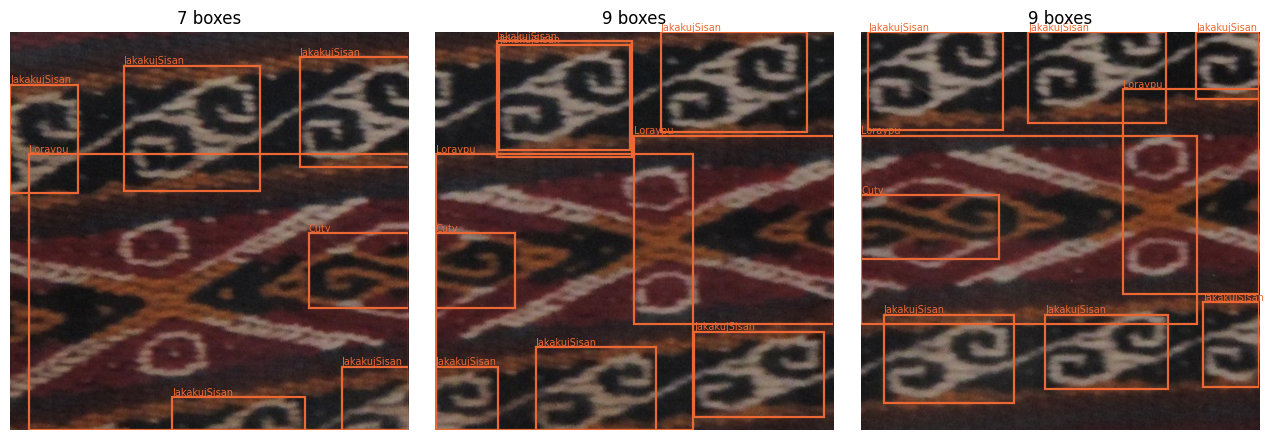

In [ ]:
# a look at three training tiles with their (re-normalized) boxes
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
show = [p for p in train_tiles if 3 <= len(tile_boxes[p.stem]) <= 9][:3]
for ax, p in zip(axes, show):
    im = Image.open(p)
    ax.imshow(im)
    bxs = [yolo_to_xyxy(cx, cy, w, h, 448, 448)
           for _, cx, cy, w, h in tile_boxes[p.stem]]
    names = [CLASS_NAMES[c] for c, *_ in tile_boxes[p.stem]]
    draw_boxes(ax, bxs, C["orange"], labels=names)
    ax.set(title=f"{len(bxs)} boxes"); ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Localization is just regression  *(~18 min)*

Strip detection to its atom: **one object, roughly centered, somewhere in the image —
predict its box and its class.** The box is 4 numbers in [0,1] → a regression head
(Lab 1). The class is a label → a classification head (Lab 2). One backbone, two
heads, one combined loss. This "localization" framing is how fast.ai and Andrew Ng
both introduce detection, and it is Section 6's grid cell in isolation.

We manufacture the training data from the annotations again: around each motif, cut a
crop with **random extra context and a random offset**, and record where the box ended
up inside that crop. (Given builder.)

In [ ]:
LOC_DIR = Path("loc_crops")
N_PER_IMG = 16 # số motif tối đa được lấy từ mỗi bức ảnh

def build_loc_crops(): # xây dựng tập dữ liệu ảnh cắt phụ vụ cho bài toán localization
    LOC_DIR.mkdir() # tạo folder chứa các file ảnh crop và file nhãn mới
    rng = np.random.default_rng(SEED)
    meta = [] # mảng rỗng để lưu nhãn (ground truth) gồm (c, x1, y1, x2, y2)
    i = 0 # biến đếm dùng đặt tên file ảnh
    for p in image_paths:
        rows = parse_yolo_file(LBL_DIR / (p.stem + ".txt")) # list các tuple 5 con số
        if not rows: continue
        img = None
        for k in rng.choice(len(rows), min(N_PER_IMG, len(rows)), replace=False):  # chọn ngẫu nhiên tối đa 16 motif
            c, cx, cy, w, h = rows[k]
            m = 1.0 + rng.uniform(0.5, 1.5) # hệ số mở rộng phông nền xung quanh
            ox, oy = rng.uniform(-.25, .25) * w, rng.uniform(-.25, .25) * h # độ xe dịch tâm để motif không nằm chính giữa ảnh crop
            Wc, Hc = w * m, h * m # kích thước chiều rộng và chiều cao ô sẽ cắt
            x0, y0 = cx + ox - Wc/2, cy + oy - Hc/2 # tọa độ top-left corner (theo tỉ lệ 0 -> 1)
            if x0 < 0 or y0 < 0 or x0 + Wc > 1 or y0 + Hc > 1: continue # Nếu ô cắt mà bị chồm ra mép ngoài -> skip
            if img is None:
                img = Image.open(p).convert("RGB")
            W, H = img.size
            crop = img.crop((x0*W, y0*H, (x0+Wc)*W, (y0+Hc)*H)).resize((96, 96)) # cắt ảnh
            crop.save(LOC_DIR / f"{i:05d}.jpg", quality=88) # lưu ảnh
            meta.append((c, (cx-w/2-x0)/Wc, (cy-h/2-y0)/Hc,     # box inside the crop,
                            (cx+w/2-x0)/Wc, (cy+h/2-y0)/Hc))    # normalized xyxy
            i += 1
    np.save(LOC_DIR / "meta.npy", np.array(meta, dtype=np.float32)) # lưu file nhãn tổng hợp meta.npy

if not LOC_DIR.exists():
    t0 = time.time(); build_loc_crops(); print(f"built in {time.time()-t0:.0f}s")
loc_meta = np.load(LOC_DIR / "meta.npy")
loc_files = sorted(LOC_DIR.glob("*.jpg"))
print(f"{len(loc_files)} localization samples "
      f"(each: 96x96 crop + class + box in crop coordinates)")

built in 225s
16531 localization samples (each: 96x96 crop + class + box in crop coordinates)


In [ ]:
class LocDataset(Dataset):
    def __init__(self, files, meta):
        self.files, self.meta = files, meta
        self.tf = transforms.Compose([transforms.Resize((96, 96)), transforms.ToTensor()])
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        img = self.tf(Image.open(self.files[i]).convert("RGB"))
        return img, int(self.meta[i, 0]), torch.tensor(self.meta[i, 1:5])

In [ ]:
def conv_block(cin, cout, stride=2):
    return nn.Sequential(nn.Conv2d(cin, cout, 3, stride, 1),
                         nn.BatchNorm2d(cout), nn.ReLU())

class LocNet(nn.Module):
    '''One backbone (Lab 4's pattern, smaller), TWO heads.'''
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = nn.Sequential(conv_block(3, 32), conv_block(32, 64),
                                      conv_block(64, 128),
                                      nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.cls_head = nn.Linear(128, num_classes)   # Lab 2 in one line
        self.box_head = nn.Linear(128, 4)             # Lab 1 in one line
    def forward(self, x):
        feats = self.backbone(x)
        classes = self.cls_head(feats)
        box_coordinates = torch.sigmoid(self.box_head(feats))
        return classes, box_coordinates
        # sigmoid: box coordinates live in [0, 1] by construction

print(LocNet(NUM_CLASSES))

LocNet(
  (backbone): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (3): AdaptiveAvgPool2d(output_size=1)
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (cls_head): Linear(in_features=128, out_features=28, bias=True)
  (box_head): Linear(in_features=128, out_features=4, bias=True)
)


### 5.1 The multi-task loss — Labs 1 and 2, added together

Two heads need two losses, summed with a weight:

$$\mathcal{L} = \underbrace{\text{CrossEntropy}(\text{class logits},\, y)}_{\text{Lab 2}}
\;+\; \lambda_{\text{box}} \cdot
\underbrace{\text{SmoothL1}(\hat{\mathbf{b}},\, \mathbf{b})}_{\text{Lab 1, robustified}}$$

SmoothL1 is MSE near zero and MAE for large errors (less dominated by outliers —
remember Lab 1's RMSE-vs-MAE discussion?). The weight $\lambda_{\text{box}}$ balances
the two objectives; detection papers agonize over such weights, we take
$\lambda_{\text{box}} = 5$.

**CrossEntropy**: Đo lường mức độ sai lệch của việc dữ đoán nhãn lớp

**SmoothL1**: Đo lường độ lệch giữa 4 tọa độ hộp dự đoán và 4 tọa độ hộp thực tế

In [ ]:
def localization_loss(class_logits, box_preds, true_labels, true_boxes,
                      box_weight=5.0):
    '''
    Combined classification + localization loss.

    Args:
        class_logits (B, num_classes) - điểm tho từ lớp Linear cuối cùng của mạng -> qua hàm softmax mới thành xác suất
        box_preds    (B, 4)           - predicted boxes in [0,1] xyxy
        true_labels  (B,) int64       - class indices
        true_boxes   (B, 4)           - ground-truth boxes
    Returns: scalar loss tensor
    '''
    ### ===== TODO 3 (≈ 3 lines) ================================= ###
    # F.cross_entropy for the class head (it takes raw logits),
    # F.smooth_l1_loss for the box head,
    # return  cls_loss + box_weight * box_loss
    cls_loss = F.cross_entropy(class_logits, true_labels)
    box_loss = F.smooth_l1_loss(box_preds, true_boxes)
    return cls_loss + box_weight * box_loss
    ### ===== END TODO ============================================ ###

<details><summary><b>Hint — TODO 3</b></summary>

`cls_loss = F.cross_entropy(class_logits, true_labels)`;
`box_loss = F.smooth_l1_loss(box_preds, true_boxes)`;
`return cls_loss + box_weight * box_loss`.
</details>

In [ ]:
# ---- Check TODO 3: localization_loss ------------------------------------------------
# Case 1: perfect predictions -> loss ~ 0
logits = torch.tensor([[20.0, -20.0]])
boxes  = torch.tensor([[0.2, 0.2, 0.6, 0.6]])
l_perfect = localization_loss(logits, boxes, torch.tensor([0]), boxes.clone())
# Case 2: confidently wrong class + boxes off by 0.5 each ->
#         CE ~ 40, SmoothL1 = 0.5*0.5^2 = 0.125 -> total ~ 40 + 5*0.125 = 40.625
l_bad = localization_loss(logits, boxes, torch.tensor([1]), boxes - 0.5)
print(f"perfect: {l_perfect.item():.4f}   (expected ~0)")
print(f"bad:     {l_bad.item():.3f}    (expected ~40.625)")
assert l_perfect is not None, "returned None"
assert l_perfect.item() < 1e-3, "perfect predictions should give ~zero loss"
assert abs(l_bad.item() - 40.625) < 0.01, "check CE + box_weight * SmoothL1"
print("PASSED: localization_loss is correct")

perfect: 0.0000   (expected ~0)
bad:     40.625    (expected ~40.625)
PASSED: localization_loss is correct


In [ ]:
# Data preparation (Dataset, DataLoader)
n = len(loc_files) # tổng số file ảnh crop
perm = np.random.default_rng(SEED).permutation(n) # tạo ra một danh sách xáo trộn các chỉ số từ 0 đến n-1
tr_i, va_i = perm[:int(0.85*n)], perm[int(0.85*n):] # 85% vào training, 15% vào validation
# Khởi tạo tập train DataLoader
loc_tr = DataLoader(LocDataset([loc_files[i] for i in tr_i], loc_meta[tr_i]),
                    batch_size=64, shuffle=True, num_workers=2)
# Khởi tạo tập Validation DataLoader
loc_va = DataLoader(LocDataset([loc_files[i] for i in va_i], loc_meta[va_i]),
                    batch_size=64, num_workers=2)

epoch  1: val mean IoU 0.579 | val cls acc 37.9%
epoch  2: val mean IoU 0.585 | val cls acc 39.1%
epoch  3: val mean IoU 0.592 | val cls acc 46.8%
epoch  4: val mean IoU 0.586 | val cls acc 45.2%
epoch  5: val mean IoU 0.593 | val cls acc 57.2%
epoch  6: val mean IoU 0.591 | val cls acc 58.1%
epoch  7: val mean IoU 0.596 | val cls acc 60.5%
epoch  8: val mean IoU 0.596 | val cls acc 60.2%
epoch  9: val mean IoU 0.598 | val cls acc 57.8%
epoch 10: val mean IoU 0.595 | val cls acc 68.2%
epoch 11: val mean IoU 0.595 | val cls acc 62.7%
epoch 12: val mean IoU 0.597 | val cls acc 64.4%
epoch 13: val mean IoU 0.595 | val cls acc 58.9%
epoch 14: val mean IoU 0.595 | val cls acc 55.3%
epoch 15: val mean IoU 0.594 | val cls acc 70.0%
epoch 16: val mean IoU 0.598 | val cls acc 65.9%
epoch 17: val mean IoU 0.594 | val cls acc 64.5%
epoch 18: val mean IoU 0.598 | val cls acc 71.7%
epoch 19: val mean IoU 0.597 | val cls acc 71.5%
epoch 20: val mean IoU 0.597 | val cls acc 67.1%
epoch 21: val mean I

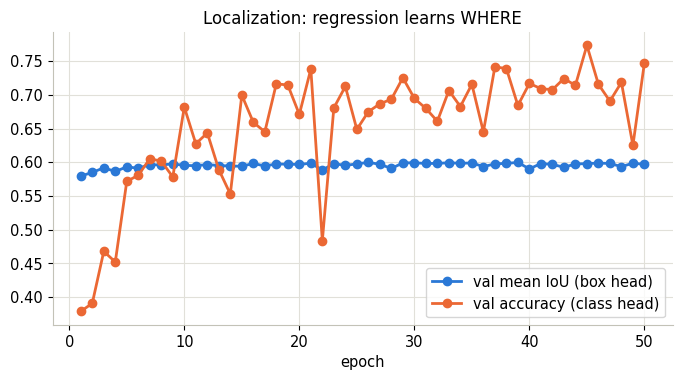

In [ ]:
locnet = LocNet(NUM_CLASSES).to(DEVICE) # khởi tạo mạng LocNet và chuyển sang GPU/CPU
opt = torch.optim.Adam(locnet.parameters(), lr=1e-3) # sử dụng thuật toán tối ưu Adam với learning rate
# LOC_EPOCHS = 8 if FAST_MODE else 15
LOC_EPOCHS = 50
iou_curve, acc_curve = [], []
for ep in range(LOC_EPOCHS):
    locnet.train()
    for xb, cb, bb in loc_tr: # lấy ra từng batch: xb (ảnh crop input), cb: nhãn lớp thực tế, bb: tọa độ khung thực tế
        xb, cb, bb = xb.to(DEVICE), cb.to(DEVICE), bb.to(DEVICE)
        logits, boxes = locnet(xb) # cho ảnh qua mạng để lấy dự đoán nhãn và dự đoán tọa độ khung
        loss = localization_loss(logits, boxes, cb, bb) # hàm loss tổng hợp
        opt.zero_grad()
        loss.backward()
        opt.step() # xóa gradient cũ, tính gradient ngược và cập nhật weights
    locnet.eval(); ious, accs = [], [] # chuyển sang chế độ đánh giá
    with torch.no_grad(): # tắt tính toán gradient
        for xb, cb, bb in loc_va:
            logits, boxes = locnet(xb.to(DEVICE))
            accs += (logits.argmax(1).cpu() == cb).tolist()
            ious += [iou(p, g) for p, g in zip(boxes.cpu().tolist(), bb.tolist())]
    iou_curve.append(np.mean(ious)); acc_curve.append(np.mean(accs))
    print(f"epoch {ep+1:2d}: val mean IoU {iou_curve[-1]:.3f} | val cls acc {acc_curve[-1]:.1%}")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(range(1, LOC_EPOCHS+1), iou_curve, "o-", color=C["blue"], lw=2, label="val mean IoU (box head)")
ax.plot(range(1, LOC_EPOCHS+1), acc_curve, "o-", color=C["orange"], lw=2, label="val accuracy (class head)")
ax.set(xlabel="epoch", title="Localization: regression learns WHERE"); ax.legend()
plt.show()

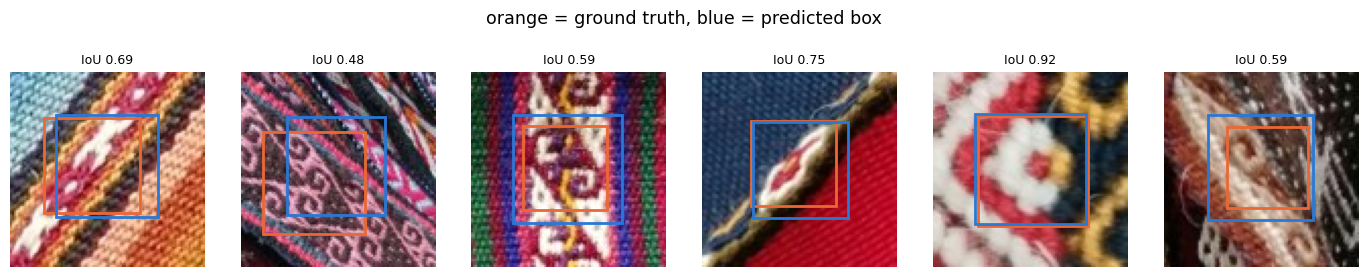

In [ ]:
# See it point (given): ground truth orange, prediction blue
locnet.eval()
fig, axes = plt.subplots(1, 6, figsize=(14, 2.6))
ds_va = LocDataset([loc_files[i] for i in va_i], loc_meta[va_i])
with torch.no_grad():
    for ax, k in zip(axes, range(6)):
        x, c_true, b_true = ds_va[k]
        logits, b_pred = locnet(x.unsqueeze(0).to(DEVICE))
        ax.imshow(x.permute(1, 2, 0))
        draw_boxes(ax, [tuple(v*96 for v in b_true.tolist())], C["orange"], lw=2)
        draw_boxes(ax, [tuple(v*96 for v in b_pred[0].cpu().tolist())], C["blue"], lw=2)
        ax.set_title(f"IoU {iou(b_pred[0].cpu().tolist(), b_true.tolist()):.2f}", fontsize=9)
        ax.axis("off")
plt.suptitle("orange = ground truth, blue = predicted box", y=1.05)
plt.tight_layout(); plt.show()

The class head lags the box head — recognizing 28 motif classes from scratch needs
more data than we gave it (Lab 4 solved exactly that problem better). Fine: the point
of this section is the blue boxes. **A network can regress "where" — everything else
in detection is bookkeeping around that fact.**

## 6. Mini-YOLO: a grid of localizers  *(~35 min)*

Now scale up from one object to many: overlay an **S×S grid** (we use S = 7) on the
tile. Each grid cell is responsible for at most one object — *the one whose center
falls inside that cell* — and predicts:

- a **confidence** (is there an object centered here?) — Lab 2, logistic
- the box **offsets** (t_x, t_y: where in the cell is the center) and **size** (w, h as
  fractions of the whole tile) — Section 5's regression
- the **class scores** — Lab 2/4.

So the prediction is a tensor of shape `(5 + num_classes, S, S)` — and this is,
minus anchor boxes and a second box per cell, YOLO v1 (2015).

### 6.1 Encoding ground truth onto the grid

Training needs targets in the same shape as predictions. Your job: place each ground-
truth box into its cell. The index math (worth doing once on paper):

- cell column `gx = int(cx * S)`, row `gy = int(cy * S)` (careful: clamp to S−1 when
  cx = 1.0 exactly)
- offset within the cell: `tx = cx*S − gx`, `ty = cy*S − gy` — both in [0, 1)
- `w, h` stay as tile fractions; the class becomes a one-hot.

**The B = 1 limitation, faced honestly:** if two boxes' centers fall in the same cell,
one must lose — keep the larger. Count the losses; that number is the price of B = 1
(real YOLO uses B ≥ 2 plus anchors — homework H4 sketches it).

In [ ]:
def encode_targets(rows, S, num_classes):
    '''
    rows: list of (class_id, cx, cy, w, h), normalized tile coordinates.
    Returns: target tensor of shape (5 + num_classes, S, S):
        channel 0     : confidence (1 where an object center lives)
        channels 1-4  : tx, ty (offset in cell), w, h (tile fractions)
        channels 5+   : one-hot class
    Collision rule: if a cell is already occupied, keep the LARGER box.
    '''
    t = torch.zeros(5 + num_classes, S, S)
    for c, cx, cy, w, h in rows:
        ### ===== TODO 4 (≈ 10 lines) ================================ ###
        # 1) gx = int(cx * S), gy = int(cy * S)  - clamp both to at most S-1
        # 2) collision: if t[0, gy, gx] == 1 already,
        #       - if the existing box (area t[3,gy,gx]*t[4,gy,gx]) is larger
        #         than w*h: `continue`
        #       - else zero out the old one-hot: t[5:, gy, gx] = 0
        # 3) write: confidence 1 at [0, gy, gx]; tx = cx*S - gx at [1,...];
        #    ty at [2,...]; w at [3,...]; h at [4,...]; one-hot at [5+c,...]
        # NOTE the indexing convention: t[channel, gy, gx] - row first!
        gx = int(cx * S)
        gy = int(cy * S)
        if t[0, gy, gx] == 1:
          if t[3, gy, gx] * t[4, gy, gx] > w * h:
            continue
          else:
            t[5:, gy, gx] = 0
        t[0, gy, gx] = 1.0                # confidence / objectness
        t[1, gy, gx] = cx * S - gx        # tx (offset relative to cell)
        t[2, gy, gx] = cy * S - gy        # ty (offset relative to cell)
        t[3, gy, gx] = w                  # width relative to tile
        t[4, gy, gx] = h                  # height relative to tile
        t[5 + c, gy, gx] = 1.0
        ### ===== END TODO ============================================ ###
    return t

<details><summary><b>Hint — TODO 4</b></summary>

`gx = min(int(cx * S), S - 1)` (same for gy with cy). Collision:
`if t[0, gy, gx] == 1:` → `if w * h <= t[3, gy, gx] * t[4, gy, gx]: continue` else
`t[5:, gy, gx] = 0`. Then write the six values; offsets are
`t[1, gy, gx] = cx * S - gx` and `t[2, gy, gx] = cy * S - gy`.
</details>

In [ ]:
# ---- Check TODO 4: encode_targets ---------------------------------------------------
# Hand-checkable: S=4, box center (0.55, 0.30) -> cx*S = 2.2 -> cell gx=2;
# cy*S = 1.2 -> gy=1; offsets tx = 0.2, ty = 0.2.
enc = encode_targets([(3, 0.55, 0.30, 0.2, 0.1)], S=4, num_classes=8)
assert enc.shape == (13, 4, 4), f"wrong shape {tuple(enc.shape)}"
assert enc[0, 1, 2] == 1.0, "confidence must be at [gy=1, gx=2] - row first!"
assert abs(enc[1, 1, 2] - 0.2) < 1e-6 and abs(enc[2, 1, 2] - 0.2) < 1e-6, "offsets wrong"
assert enc[3, 1, 2] == 0.2 and abs(enc[4, 1, 2] - 0.1) < 1e-6, "w, h wrong"
assert enc[5 + 3, 1, 2] == 1.0 and enc[0].sum() == 1.0, "one-hot / confidence wrong"

# collision: two boxes in the same cell -> the larger (class 7) must win
enc2 = encode_targets([(3, 0.51, 0.51, 0.1, 0.1), (7, 0.55, 0.55, 0.3, 0.3)],
                      S=2, num_classes=8)
assert enc2[0].sum() == 1.0 and enc2[5 + 7, 1, 1] == 1.0 and enc2[3, 1, 1] == 0.3, \
    "collision rule: the larger box must survive"
print("PASSED: encode_targets is correct")

PASSED: encode_targets is correct


### 6.2 Decoding: from grid back to boxes

Inference needs the inverse: walk the grid, keep cells with confidence above a
threshold, and reconstruct each box from its cell index + offsets. Write the inverse
of your own encoder. (The check is a beautiful property test: **decode(encode(boxes))
must return the boxes**.)

In [ ]:
def decode_grid(grid, S, conf_threshold=0.35):
    '''
    grid: (5 + C, S, S) tensor with confidence/coords already in [0, 1]
          (a ground-truth target, or a prediction AFTER activation).
    Returns: (boxes, scores, class_ids) - boxes as normalized xyxy tuples.
    '''
    boxes, scores, class_ids = [], [], []
    ### ===== TODO 5 (≈ 10 lines) ================================ ###
    # Loop gy in range(S), gx in range(S):
    #   conf = grid[0, gy, gx]; skip if below conf_threshold
    #   tx, ty, w, h = grid[1:5, gy, gx]
    #   center: cx = (gx + tx) / S ;  cy = (gy + ty) / S     <- undo TODO 4!
    #   append ((cx-w/2, cy-h/2, cx+w/2, cy+h/2)), the conf, and
    #   the argmax of grid[5:, gy, gx] as the class id
    for gy in range(S):
        for gx in range(S):
            conf = grid[0, gy, gx]
            if conf < conf_threshold:
                continue

            tx, ty, w, h = grid[1:5, gy, gx]
            cx = (gx + tx) / S
            cy = (gy + ty) / S

            x1 = cx - w / 2
            y1 = cy - h / 2
            x2 = cx + w / 2
            y2 = cy + h / 2

            class_id = int(grid[5:, gy, gx].argmax())

            boxes.append((x1, y1, x2, y2))
            scores.append(float(conf))
            class_ids.append(class_id)
    ### ===== END TODO ============================================ ###
    return boxes, scores, class_ids

<details><summary><b>Hint — TODO 5</b></summary>

The inverse of `tx = cx*S − gx` is `cx = (gx + tx) / S`. Convert center format to
corners exactly like Lab 4's `yolo_to_xyxy` (but everything stays normalized, so no
W/H multiplication). Class id: `int(grid[5:, gy, gx].argmax())`.
</details>

In [ ]:
# ---- Check TODO 5: the encode->decode roundtrip -------------------------------------
rows_rt = [(3, 0.55, 0.30, 0.20, 0.10), (7, 0.10, 0.90, 0.15, 0.20)]
dec_b, dec_s, dec_c = decode_grid(encode_targets(rows_rt, 7, NUM_CLASSES), 7, 0.5)
assert dec_b, "decode returned nothing - check the confidence threshold logic"
assert sorted(dec_c) == [3, 7], f"classes {dec_c}, expected [3, 7]"
for (c0, cx, cy, w, h) in rows_rt:
    target = (cx - w/2, cy - h/2, cx + w/2, cy + h/2)
    best = max(iou(target, b) for b in dec_b)
    assert best > 0.999, f"roundtrip lost a box (best IoU {best:.3f})"
print("PASSED: decode_grid inverts encode_targets exactly")

PASSED: decode_grid inverts encode_targets exactly


### 6.3 The model and the loss *(given — read the comments)*

The model is Lab 4's conv-block pattern: five stride-2 blocks take 224×224 → 7×7, and
a 1×1 convolution turns the 7×7 feature map into the 7×7 **prediction grid** — one
(5+C)-vector per cell. No flattening, no giant Linear: the grid structure comes for
free from convolution. *(This is the deep reason detection loves CNNs: a conv feature
map already IS a grid of local descriptions.)*

The loss is three familiar losses masked onto the right cells — YOLO v1's loss,
simplified to B = 1:

| term | applies to | loss | λ |
|---|---|---|---|
| confidence | every cell (object *and* empty) | BCE | 1 for object cells, **0.5** for empty (they vastly outnumber object cells) |
| box (tx, ty, w, h) | object cells only | SmoothL1 | **5** (localization is the point) |
| class | object cells only | BCE on one-hot | 1 |

In [ ]:
S = 7
IMG_SIZE = 224

class MiniYolo(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = nn.Sequential(
            conv_block(3, 32), conv_block(32, 64), conv_block(64, 128),
            conv_block(128, 128), conv_block(128, 256))     # 224 -> 7x7
        self.head = nn.Conv2d(256, 5 + num_classes, kernel_size=1)
    def forward(self, x):
        return self.head(self.backbone(x))                  # (B, 5+C, 7, 7) raw


In [ ]:
def activate(pred):
    '''Raw head output -> [0,1] confidence and coordinates (class logits stay raw:
    decode_grid only needs their argmax).'''
    return torch.cat([torch.sigmoid(pred[:5]), pred[5:]], dim=0)

def yolo_loss(pred, target, l_coord=5.0, l_noobj=0.5):
    obj = target[:, 0:1]                                     # (B,1,S,S) object mask
    # confidence: BCE everywhere, down-weighted on empty cells
    conf = F.binary_cross_entropy_with_logits(pred[:, 0:1], obj, reduction="none")
    conf_loss = (obj * conf + l_noobj * (1 - obj) * conf).sum()
    # box: SmoothL1, object cells only (the mask kills empty-cell gradients)
    box_loss = (obj * F.smooth_l1_loss(torch.sigmoid(pred[:, 1:5]),
                                       target[:, 1:5], reduction="none")).sum()
    # class: BCE against the one-hot, object cells only
    cls_loss = (obj * F.binary_cross_entropy_with_logits(pred[:, 5:], target[:, 5:],
                                                         reduction="none")).sum()
    return (conf_loss + l_coord * box_loss + cls_loss) / pred.shape[0]



In [ ]:
class TileDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                      transforms.ToTensor()])
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        p = self.paths[i]
        return (self.tf(Image.open(p).convert("RGB")),
                encode_targets(tile_boxes[p.stem], S, NUM_CLASSES))

In [ ]:
model = MiniYolo(NUM_CLASSES).to(DEVICE)
print(f"MiniYolo: {sum(p.numel() for p in model.parameters()):,} parameters "
      f"-> output grid (5+{NUM_CLASSES}, {S}, {S})")

MiniYolo: 545,697 parameters -> output grid (5+28, 7, 7)


### 6.4 Train it — and load the shipped checkpoint

From-scratch detectors are data- and compute-hungry (the original YOLO trained for a
week). Our strategy — the same one used by every teaching resource from Andrew Ng's
course (pretrained weights) to the reference "YOLO from scratch" tutorials (overfit
100 images) — is honest miniaturization: **overfit a small set of tiles** so you can
watch the mechanism work, then load a **checkpoint we trained longer** for the
evaluation sections. Homework H2 scales up on the full dataset with GPU.

epoch   0: loss    44.45  (52s)
epoch  12: loss    18.05  (673s)
epoch  24: loss    10.84  (1292s)
epoch  36: loss     7.45  (1919s)
epoch  48: loss     5.77  (2545s)
epoch  60: loss     4.81  (3163s)
epoch  72: loss     4.11  (3788s)
epoch  84: loss     3.67  (4410s)
epoch  96: loss     3.33  (5043s)
epoch  99: loss     3.30  (5199s)


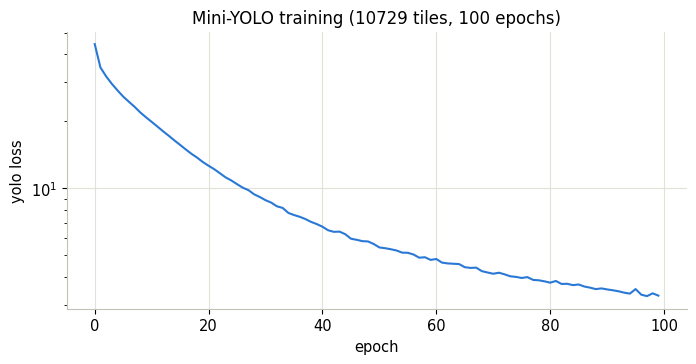

In [ ]:
YOLO_TILES = 96 if FAST_MODE else len(train_tiles)
# YOLO_EPOCHS = 25 if FAST_MODE else 120
YOLO_EPOCHS = 100
sub_tiles = train_tiles[:YOLO_TILES]
dl = DataLoader(TileDataset(sub_tiles), batch_size=16, shuffle=True, num_workers=2)

opt = torch.optim.Adam(model.parameters(), lr=3e-4)
loss_hist = []
t0 = time.time()
for ep in range(YOLO_EPOCHS):
    model.train(); tot = 0
    for xb, tb in dl:
        loss = yolo_loss(model(xb.to(DEVICE)), tb.to(DEVICE))
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() * len(xb)
    loss_hist.append(tot / len(sub_tiles))
    if ep % max(1, YOLO_EPOCHS // 8) == 0 or ep == YOLO_EPOCHS - 1:
        print(f"epoch {ep:3d}: loss {loss_hist[-1]:8.2f}  ({time.time()-t0:.0f}s)")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(loss_hist, color=C["blue"])
ax.set(xlabel="epoch", ylabel="yolo loss", yscale="log",
       title=f"Mini-YOLO training ({YOLO_TILES} tiles, {YOLO_EPOCHS} epochs)")
plt.show()

In [ ]:
# Save model
torch.save(model, "/content/drive/MyDrive/BrocadeAI/mini_yolo.pt")

loaded checkpoint: 160 tiles (72-image sample), 220 epochs, CPU


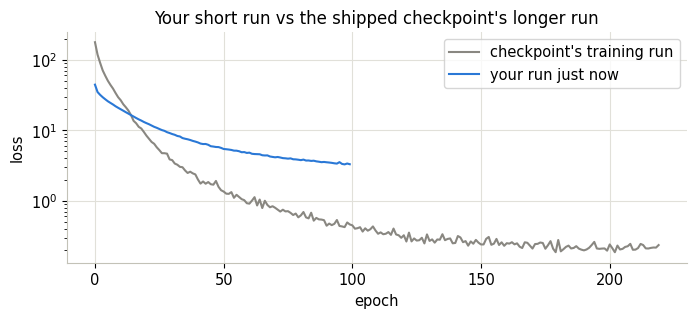

model set to eval mode (Lab 4's lesson - BatchNorm behaves differently in train mode!)


In [ ]:
# Load the shipped checkpoint (trained the same way, just longer) if available.
CKPT = Path("/content/drive/MyDrive/miniyolo_checkpoint.pt")
if CKPT.exists():
    ck = torch.load(CKPT, map_location="cpu", weights_only=False)
    model = MiniYolo(len(ck["classes"])).to(DEVICE)
    model.load_state_dict(ck["state_dict"])
    print("loaded checkpoint:", ck["trained_on"])
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(ck["loss_history"], color=C["muted"], label="checkpoint's training run")
    ax.plot(loss_hist, color=C["blue"], label="your run just now")
    ax.set(xlabel="epoch", ylabel="loss", yscale="log",
           title="Your short run vs the shipped checkpoint's longer run")
    ax.legend(); plt.show()
else:
    print("no checkpoint found - continuing with the model you just trained")
model.eval()
print("model set to eval mode (Lab 4's lesson - BatchNorm behaves differently in train mode!)")

### 6.5 See it detect — and watch NMS earn its keep

The full inference pipeline, all yours: `model` → `activate` → **your** `decode_grid`
→ **your** `nms`. Ground truth in orange, predictions in blue.

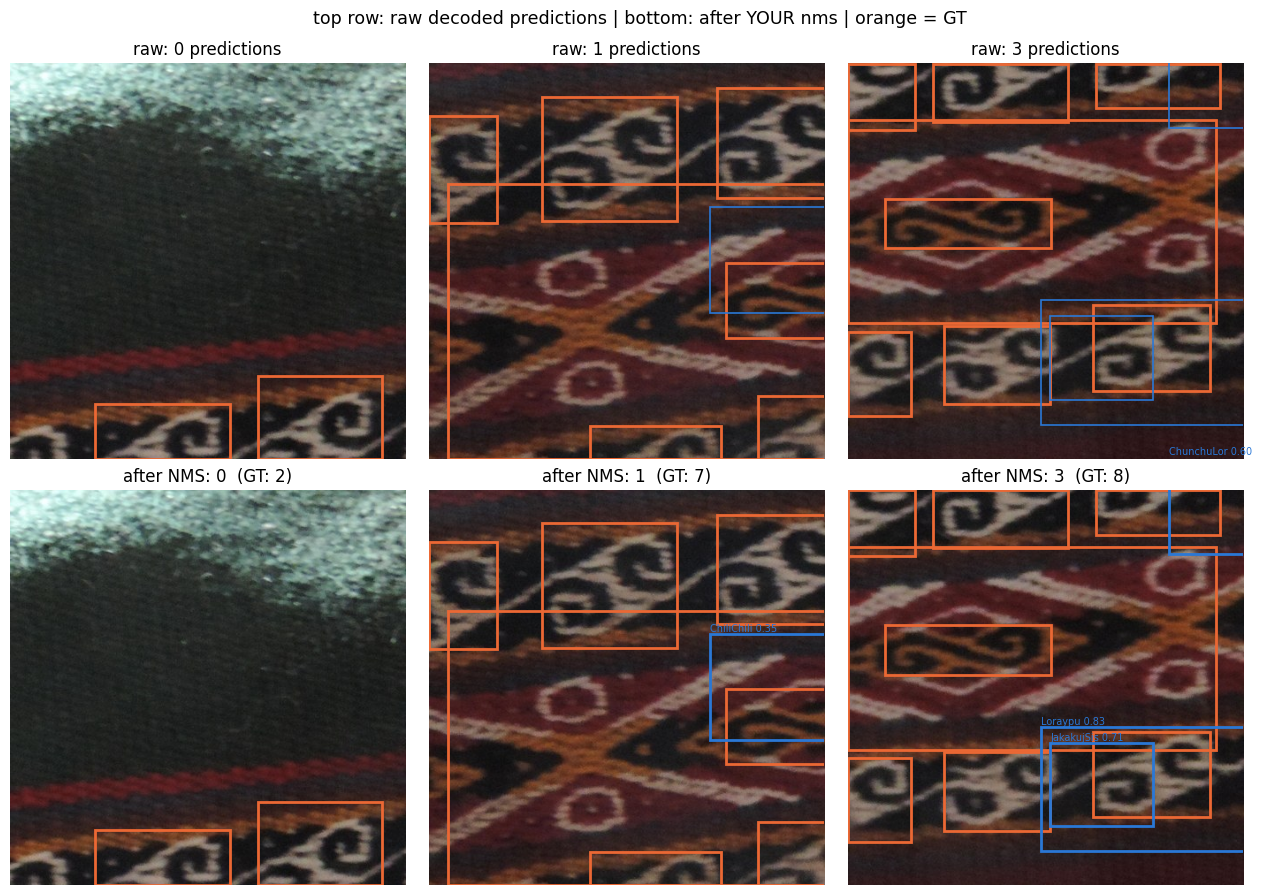

In [ ]:
def detect(tile_path, conf=0.35, nms_iou=0.4):
    tf = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                             transforms.ToTensor()])
    x = tf(Image.open(tile_path).convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        grid = activate(model(x)[0].cpu())
    boxes, scores, cls_ids = decode_grid(grid, S, conf)
    keep = nms(boxes, scores, nms_iou)
    return ([boxes[i] for i in keep], [scores[i] for i in keep],
            [cls_ids[i] for i in keep], boxes)

# show tiles the checkpoint has seen (train) - homework H2 makes val tiles look this good
demo_tiles = [p for p in sub_tiles if 2 <= len(tile_boxes[p.stem]) <= 8][:3]
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for col, p in enumerate(demo_tiles):
    im = Image.open(p)
    gt = [yolo_to_xyxy(cx, cy, w, h, 448, 448) for _, cx, cy, w, h in tile_boxes[p.stem]]
    kept_b, kept_s, kept_c, raw_b = detect(p)
    ax = axes[0, col]
    ax.imshow(im); draw_boxes(ax, gt, C["orange"], lw=2)
    draw_boxes(ax, [tuple(v*448 for v in b) for b in raw_b], C["blue"], lw=1.2)
    ax.set(title=f"raw: {len(raw_b)} predictions"); ax.axis("off")
    ax = axes[1, col]
    ax.imshow(im); draw_boxes(ax, gt, C["orange"], lw=2)
    draw_boxes(ax, [tuple(v*448 for v in b) for b in kept_b], C["blue"], lw=2,
               labels=[f"{CLASS_NAMES[c][:10]} {s:.2f}" for c, s in zip(kept_c, kept_s)])
    ax.set(title=f"after NMS: {len(kept_b)}  (GT: {len(gt)})"); ax.axis("off")
plt.suptitle("top row: raw decoded predictions | bottom: after YOUR nms | orange = GT",
             y=0.99)
plt.tight_layout(); plt.show()

## 7. Honest evaluation: precision, recall, AP@0.5  *(~12 min)*

Classification metrics don't transfer directly — a detection can be wrong in three
ways (missed object, phantom box, right object/wrong place). The standard protocol:

1. **Match** predictions to ground truth, greedily, best score first: a prediction is
   a **TP** if it overlaps an *unmatched* GT box with IoU ≥ 0.5, else an **FP**.
   Unmatched GT boxes are **FN** — Lab 2's confusion vocabulary, one IoU twist.
2. Sweep the confidence threshold (Lab 2's threshold lesson) → **precision-recall
   curve**; the area under it is **AP@0.5** (averaged over classes → the "mAP" of
   every detection paper).

(Given code — but notice it is built entirely from YOUR `iou`, `decode_grid` and
`nms`.)

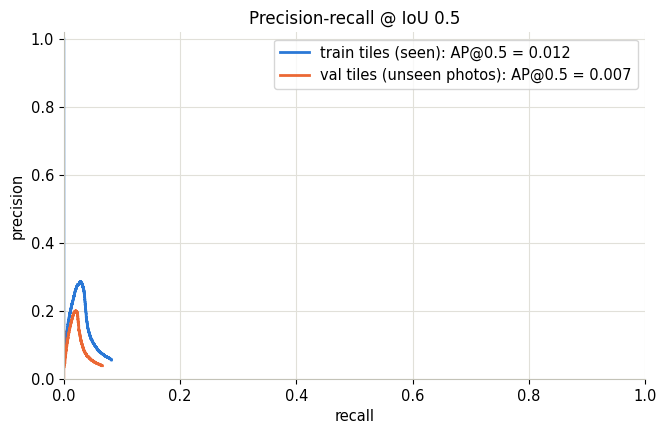

evaluated on 2748 tiles per split (25876 GT boxes in val)


In [ ]:
def match_detections(pred_boxes, pred_scores, gt_boxes, iou_thr=0.5):
    '''Greedy matching. Returns list of (score, is_tp) + number of GT boxes.'''
    order = sorted(range(len(pred_boxes)), key=lambda i: pred_scores[i], reverse=True)
    matched = set()
    out = []
    for i in order:
        best_iou, best_j = 0.0, None
        for j, g in enumerate(gt_boxes):
            if j in matched: continue
            v = iou(pred_boxes[i], g)
            if v > best_iou: best_iou, best_j = v, j
        if best_iou >= iou_thr:
            matched.add(best_j); out.append((pred_scores[i], True))
        else:
            out.append((pred_scores[i], False))
    return out, len(gt_boxes)

def evaluate_ap(tiles, conf=0.05, nms_iou=0.4):
    '''AP@0.5 over a set of tiles (class-agnostic, to keep the mechanics visible).'''
    records, total_gt = [], 0
    for p in tiles:
        gt = [ (cx-w/2, cy-h/2, cx+w/2, cy+h/2)
               for _, cx, cy, w, h in tile_boxes[p.stem] ]
        kept_b, kept_s, _, _ = detect(p, conf=conf, nms_iou=nms_iou)
        recs, n_gt = match_detections(kept_b, kept_s, gt)
        records += recs; total_gt += n_gt
    records.sort(key=lambda r: -r[0])
    tps = np.cumsum([r[1] for r in records])
    fps = np.cumsum([not r[1] for r in records])
    recall = tps / max(total_gt, 1)
    precision = tps / np.maximum(tps + fps, 1)
    ap = float(np.trapezoid(precision, recall))
    return ap, precision, recall, total_gt

N_EVAL = 40 if FAST_MODE else len(val_tiles)
ap_tr, prec_tr, rec_tr, _ = evaluate_ap(sub_tiles[:N_EVAL])
ap_va, prec_va, rec_va, n_gt_va = evaluate_ap(val_tiles[:N_EVAL])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(rec_tr, prec_tr, color=C["blue"], lw=2,
        label=f"train tiles (seen): AP@0.5 = {ap_tr:.3f}")
ax.plot(rec_va, prec_va, color=C["orange"], lw=2,
        label=f"val tiles (unseen photos): AP@0.5 = {ap_va:.3f}")
ax.set(xlabel="recall", ylabel="precision", xlim=(0, 1), ylim=(0, 1.02),
       title="Precision-recall @ IoU 0.5")
ax.legend()
plt.show()
print(f"evaluated on {N_EVAL} tiles per split ({n_gt_va} GT boxes in val)")

**Read this plot with Lab 3 eyes.** The gap between the blue curve (tiles the
checkpoint trained on) and the orange one (tiles from photographs it has never seen)
is *variance* — we deliberately overfit a small tile set, and the evaluation says so
without mercy. This is the honest baseline that homework H2 (train on ALL tiles, GPU,
longer) exists to improve. The *mechanics* — matching, PR curve, AP — are exactly what
COCO leaderboards compute, just with more classes and IoU thresholds.

## 8. The industry detector: same contract, bigger machine  *(~8 min)*

Everything you built has a production-grade counterpart inside
`torchvision`'s **Faster R-CNN**: a pretrained CNN backbone (Lab 4 H3's transfer
learning), a *region proposal network* instead of a fixed grid, thousands of anchor
boxes instead of 49 cells, the same NMS at the end. The remarkable part is the
**interface**: it consumes exactly the `(image, {"boxes", "labels"})` samples and
list-collate you built in Lab 4 — your data pipeline was industry-standard all along.

*(One quirk: torchvision reserves label 0 for "background", so our class ids shift
by +1. On Colab the pretrained backbone downloads automatically; if the download is
blocked, the demo falls back to random weights — the API lesson is unchanged, the
boxes will just be bad.)*

In [ ]:
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_320_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

try:
    frcnn = fasterrcnn_mobilenet_v3_large_320_fpn(weights="DEFAULT")
    print("pretrained COCO backbone loaded")
except Exception:
    # no download access: random init (note weights_backbone=None too, or
    # torchvision would still try to download the backbone weights!)
    frcnn = fasterrcnn_mobilenet_v3_large_320_fpn(weights=None, weights_backbone=None)
    print("pretrained weights unavailable here - using random init (API demo only)")

in_feats = frcnn.roi_heads.box_predictor.cls_score.in_features
frcnn.roi_heads.box_predictor = FastRCNNPredictor(in_feats, NUM_CLASSES + 1)  # +1 bg

class TileDetectionDataset(Dataset):
    '''Lab 4's detection contract, verbatim - this feeds Faster R-CNN directly.'''
    def __init__(self, paths):
        self.paths = paths
        self.tf = transforms.ToTensor()
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        p = self.paths[i]
        img = Image.open(p).convert("RGB")
        rows = tile_boxes[p.stem]
        boxes = torch.tensor([yolo_to_xyxy(cx, cy, w, h, 448, 448)
                              for _, cx, cy, w, h in rows],
                             dtype=torch.float32).reshape(-1, 4)
        labels = torch.tensor([c + 1 for c, *_ in rows], dtype=torch.int64)
        return self.tf(img), {"boxes": boxes, "labels": labels}

def detection_collate(batch):
    return tuple(zip(*batch))

frcnn_tiles = [p for p in train_tiles if len(tile_boxes[p.stem]) > 0][:32 if FAST_MODE else 200]
frcnn_dl = DataLoader(TileDetectionDataset(frcnn_tiles), batch_size=4,
                      shuffle=True, collate_fn=detection_collate)

frcnn.to(DEVICE).train()
opt = torch.optim.SGD([p for p in frcnn.parameters() if p.requires_grad],
                      lr=5e-3, momentum=0.9)
t0 = time.time()
FULL_EPOCHS = 100
for ep in range(1 if FAST_MODE else FULL_EPOCHS):
    for images, targets in frcnn_dl:
        images = [im.to(DEVICE) for im in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        loss_dict = frcnn(images, targets)          # train mode: returns the losses
        loss = sum(loss_dict.values())              # RPN + classifier + box losses
        opt.zero_grad(); loss.backward(); opt.step()
    print(f"epoch {ep}: total loss {loss.item():.3f} "
          f"(components: {sorted(loss_dict)})  ({time.time()-t0:.0f}s)")
print("\nNote the loss components - proposal objectness + box regression (the RPN's")
print("'is something here?' = our confidence channel) and classifier + box refinement")
print("(= our class and coordinate channels). Same anatomy, two stages.")
torch.save(frcnn, "/content/drive/MyDrive/BrocadeAI/frcnn.pt")

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_320_fpn-907ea3f9.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_320_fpn-907ea3f9.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 200MB/s]


pretrained COCO backbone loaded
epoch 0: total loss 1.938 (components: ['loss_box_reg', 'loss_classifier', 'loss_objectness', 'loss_rpn_box_reg'])  (7s)
epoch 1: total loss 1.352 (components: ['loss_box_reg', 'loss_classifier', 'loss_objectness', 'loss_rpn_box_reg'])  (12s)
epoch 2: total loss 1.215 (components: ['loss_box_reg', 'loss_classifier', 'loss_objectness', 'loss_rpn_box_reg'])  (16s)
epoch 3: total loss 1.255 (components: ['loss_box_reg', 'loss_classifier', 'loss_objectness', 'loss_rpn_box_reg'])  (21s)
epoch 4: total loss 1.251 (components: ['loss_box_reg', 'loss_classifier', 'loss_objectness', 'loss_rpn_box_reg'])  (24s)
epoch 5: total loss 1.011 (components: ['loss_box_reg', 'loss_classifier', 'loss_objectness', 'loss_rpn_box_reg'])  (28s)
epoch 6: total loss 0.949 (components: ['loss_box_reg', 'loss_classifier', 'loss_objectness', 'loss_rpn_box_reg'])  (32s)
epoch 7: total loss 1.427 (components: ['loss_box_reg', 'loss_classifier', 'loss_objectness', 'loss_rpn_box_reg']) 

## 9. Wrap-up  *(~3 min)*

The series, complete:

- **Lab 1** — regression, gradient descent, the golden rule.
- **Lab 2** — classification, thresholds as policy.
- **Lab 3** — complexity control, honest evaluation.
- **Lab 4** — the image pipeline, CNN backbones.
- **Lab 5** — detection = everything above, composed: a grid of (Lab 1 regression +
  Lab 2 classification) heads on a Lab 4 backbone, tuned and judged with Lab 3
  discipline.

Ideas worth remembering verbatim:

1. **IoU is detection's ruler** — training targets, NMS, and evaluation all consume it.
2. **NMS is a 7-line greedy loop** — keep the best, kill its overlaps, repeat.
3. **A detector head predicts numbers, not mysteries**: confidence (logistic), offsets
   and sizes (regression), classes (classification) — per grid cell.
4. **encode and decode must be exact inverses** — the roundtrip test caught more bugs
   in real projects than any other single check.
5. **Split where samples are independent** (photographs, not tiles) — leakage trap #4.
6. **Dense small objects → tile**; one box per cell is a real, countable limitation
   (anchors and B>1 exist to fix exactly that).
7. **Evaluation is matching + a threshold sweep** — AP@0.5 is Lab 2's PR curve wearing
   an IoU costume.

---

## Homework

**H1 — Threshold engineering.** Sweep `conf` ∈ {0.1 … 0.7} and `nms_iou` ∈ {0.3, 0.4,
0.5, 0.6} on the validation tiles; report the best F1@IoU0.5 combination. Which knob
trades precision for recall, and which controls duplicate suppression? (Lab 2's
threshold-as-policy, now in 2-D.)

**H2 — Train it for real** *(Colab GPU)*. Tile the full 1,358-image dataset
(`FAST_MODE=False` handles it), train mini-YOLO on all train tiles for 120+ epochs
(~minutes on a T4), and re-run Section 7. Report train/val AP@0.5 and compare with the
shipped checkpoint. How much of the gap was data, how much was epochs?

**H3 — Per-class evaluation.** Extend `evaluate_ap` to match per class and produce an
AP table for the 10 most frequent motifs. Which classes fail hardest — and does the
Lab 4 EDA (box size, class frequency) predict the ranking?

**H4 — Stretch: design for B = 2.** Count how many GT boxes the B = 1 encoder discards
on the training tiles (add a counter to `encode_targets`). Then sketch — on paper, no
implementation — what changes in the target tensor, the loss, and NMS if every cell
predicts two boxes with different aspect-ratio priors (anchors). You have just
re-derived YOLO v2's core idea.

---

## References and further reading

- J. Redmon et al., *You Only Look Once: Unified, Real-Time Object Detection* (2016) —
  this lab's Section 6 is its §2, simplified to B=1.
- S. Ren et al., *Faster R-CNN* (2015) — Section 8's two-stage design.
- A. Ng, *Deep Learning Specialization* C4W3 — IoU/NMS as student exercises on a
  pretrained YOLO (this lab's Sections 2–3 follow that template, then goes further and
  trains the model).
- *Dive into Deep Learning* ch. 14.3–14.7 — anchors and SSD, the natural next reading
  after H4.
- TorchVision Object Detection Finetuning tutorial — Section 8, industrial strength.
- Dataset: *Iconography of Chinchero* (Data in Brief 2026, CC BY 4.0).